<a href="https://colab.research.google.com/github/anu-v-nair/executive_program_in_advanced_ai_ml_iit_palakkad/blob/main/AI_Driven_Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [693]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score

In [694]:
filepath = "/content/employee_attrition_dataset_10000.csv"
Data = pd.read_csv(filepath)
df = Data.copy()

# Basic Dataset Exploration

In [695]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [696]:
df.shape

(10000, 26)

In [697]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

# Missing Value Analysis

In [698]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


In [699]:
df.isna().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


# Duplicate Checking

In [700]:
df.duplicated().sum()

np.int64(0)

# Statistical Summary

In [701]:
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,39.561800,2.990800,11436.716700,57.032300,14.936200,7.451300,4.471900,2.502400,3.038000,2.507700,49.588900,4.984400,44.473500,9.410200,2.493100,2.491400,2.505400,25.272000,2.516600
std,2886.89568,11.454986,1.410643,4926.528302,24.703261,8.431657,4.042903,2.891617,1.112348,1.414764,1.120833,28.801393,2.580043,8.611662,5.760335,1.120927,1.115101,1.116018,14.219474,1.113934
min,1.00000,20.000000,1.000000,3000.000000,15.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,30.000000,2.000000,7182.500000,36.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,25.000000,3.000000,37.000000,4.000000,1.000000,1.000000,2.000000,13.000000,2.000000
50%,5000.50000,40.000000,3.000000,11401.500000,57.000000,15.000000,7.000000,4.000000,2.000000,3.000000,3.000000,49.000000,5.000000,45.000000,9.000000,2.000000,2.000000,3.000000,25.000000,2.000000
75%,7500.25000,49.000000,4.000000,15679.500000,78.000000,22.000000,11.000000,7.000000,3.000000,4.000000,4.000000,75.000000,7.000000,52.000000,14.000000,4.000000,3.000000,3.000000,37.000000,4.000000
max,10000.00000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.000000,4.000000,5.000000,4.000000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


# Datatype Analysis

In [702]:
df.dtypes

,0
Employee_ID,int64
Age,int64
Gender,object
Marital_Status,object
Department,object
Job_Role,object
Job_Level,int64
Monthly_Income,int64
Hourly_Rate,int64
Years_at_Company,int64


In [703]:
df['Income_Band'] = pd.qcut(df['Monthly_Income'], 4, labels=False)

In [704]:
df['Experience_Level'] = pd.cut(df['Years_at_Company'],5,labels=False)

In [705]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition,Income_Band,Experience_Level
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,48,16,4,1,1,49,3,No,1,4
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,57,10,4,1,1,25,1,No,0,3
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,55,1,1,4,3,21,1,Yes,2,0
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,53,2,3,4,1,46,2,No,3,1
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,54,11,1,1,1,43,4,No,3,0


# 3. Exploratory Data Analysis (EDA)

# Attrition Distribution

/tmp/ipykernel_1071/1714326748.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='gist_heat')


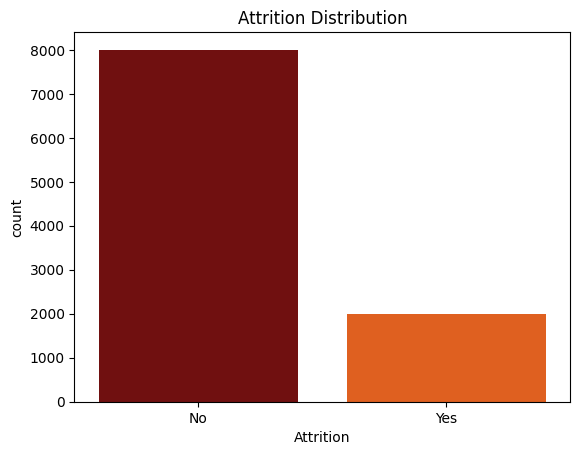

In [706]:
sns.countplot(x='Attrition', data=df, palette='gist_heat')
plt.title('Attrition Distribution')
plt.show()

# Attrition by Overtime

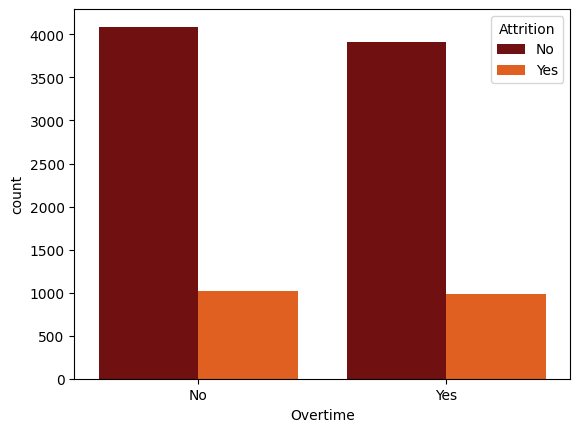

In [707]:
sns.countplot(x='Overtime', hue='Attrition', data=df, palette='gist_heat')
plt.show()

# Attrition by Monthly Income

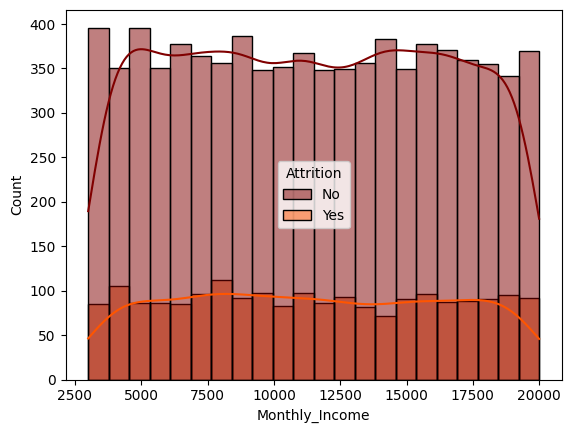

In [708]:
sns.histplot(x='Monthly_Income', hue='Attrition', data=df, kde=True, multiple = 'layer',palette='gist_heat')
plt.show()

# Attrition by Job Satisfaction

/tmp/ipykernel_1071/3124944156.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Attrition', y='Job_Satisfaction', data=df, palette = "gist_heat")


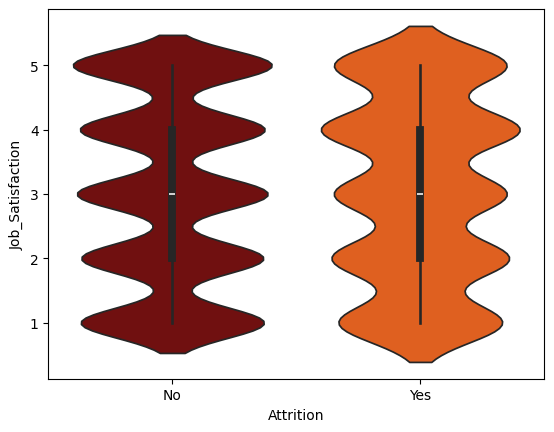

In [709]:
sns.violinplot(x='Attrition', y='Job_Satisfaction', data=df, palette = "gist_heat")
plt.show()

# Correlation Heatmap

In [710]:
num_cols = [col for col in df.columns if df[col].dtypes != "O"]

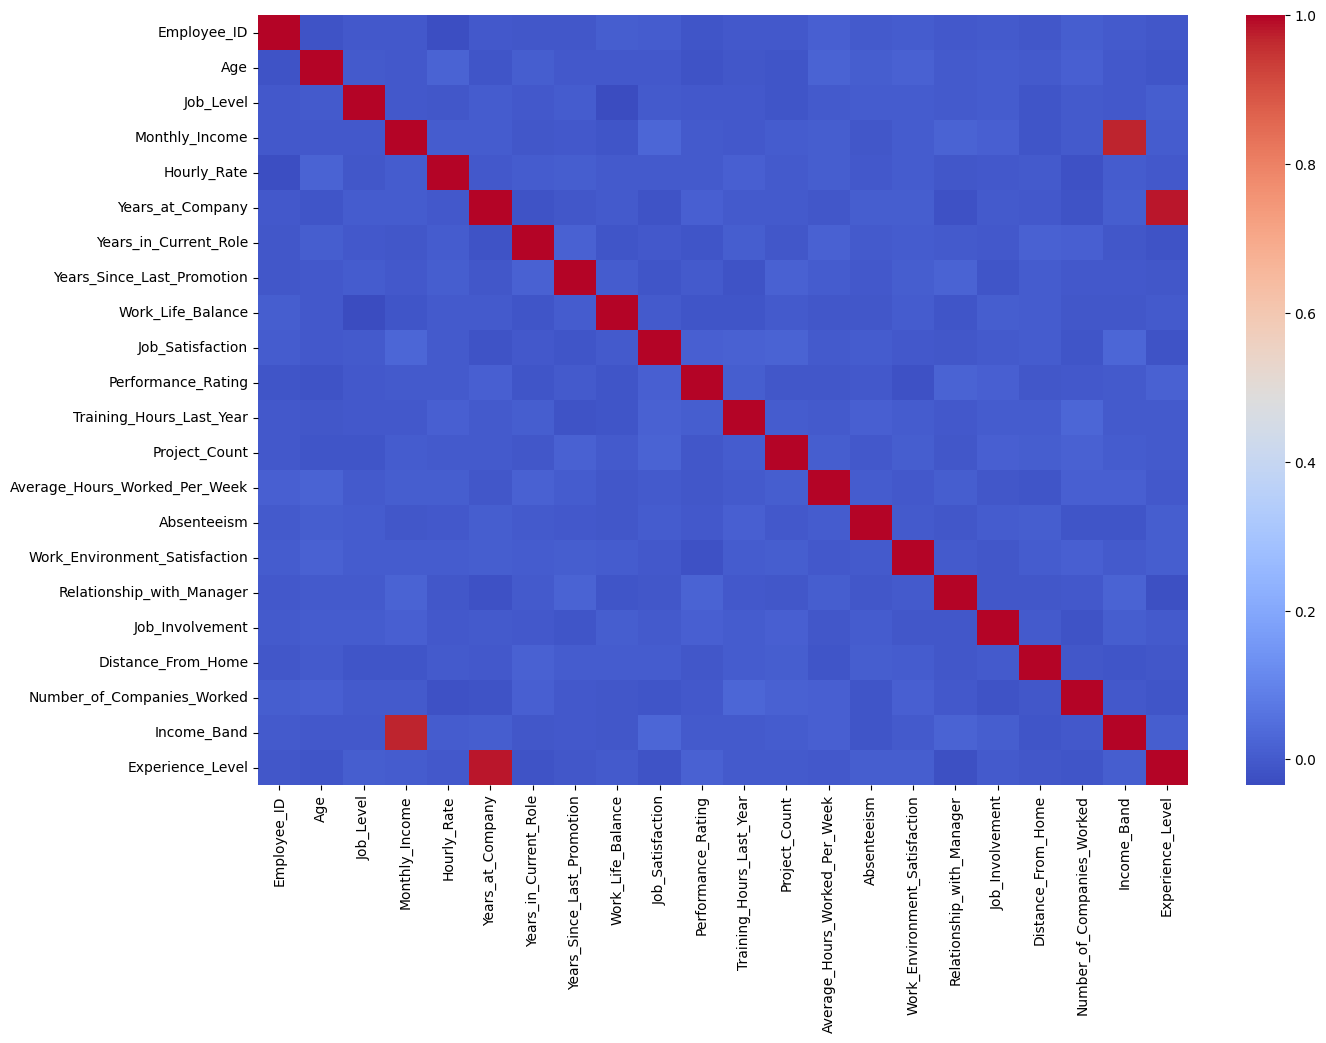

In [711]:
plt.figure(figsize=(15,10))
correlation = df[num_cols].corr()
sns.heatmap(correlation, cmap='coolwarm')
plt.show()

# 4. Data Preprocessing

# Dropping Unnecessary Columns

In [712]:
df.drop('Employee_ID', axis=1, inplace=True)

# Encoding Target Variable

In [713]:
df['Attrition'] = df['Attrition'].map({'No':0, 'Yes':1})

# Separating Features and Target

In [714]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# One Hot Encoding for Categorical Variables

In [715]:
cat_cols = X.select_dtypes(include='object').columns
cat_cols

Index(['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime'], dtype='object')

In [716]:
num_cols = X.select_dtypes(exclude='object').columns
num_cols

Index(['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company',
       'Years_in_Current_Role', 'Years_Since_Last_Promotion',
       'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating',
       'Training_Hours_Last_Year', 'Project_Count',
       'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Income_Band', 'Experience_Level'],
      dtype='object')

In [717]:
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown='ignore')

In [718]:
encoded_cols = ohe.fit_transform(X[cat_cols])

In [719]:
encoded_cols

array([[1., 0., 1., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 1.],
       ...,
       [1., 0., 0., ..., 0., 1., 1.],
       [0., 0., 1., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 0., 1.]])

In [720]:
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(cat_cols),index=X.index)

In [721]:
encoded_df

,Gender_Male,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
9996,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
9998,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [722]:
X=pd.concat([X[num_cols], encoded_df], axis=1)

In [723]:
X

,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,58,5,7332,81,24,12,3,1,3,2,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,48,4,6069,55,18,7,5,1,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,34,4,11485,65,6,4,3,4,5,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,27,4,18707,28,12,9,1,1,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,40,1,16398,92,3,9,1,3,4,3,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,22,5,4276,27,17,5,1,3,5,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
9996,35,3,10327,60,19,11,6,2,1,4,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9997,23,3,12592,68,10,11,4,4,2,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
9998,42,3,9287,26,18,7,8,1,5,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [724]:
# df.drop(columns=cat_cols,axis=1,inplace=True)

In [725]:
df.head(2)

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition,Income_Band,Experience_Level
0,58,Male,Single,Finance,Manager,5,7332,81,24,12,...,48,16,4,1,1,49,3,0,1,4
1,48,Female,Divorced,HR,Assistant,4,6069,55,18,7,...,57,10,4,1,1,25,1,0,0,3


In [726]:
# X = df.drop(['Attrition'], axis=1)
# y = df['Attrition']

In [727]:
X

,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,58,5,7332,81,24,12,3,1,3,2,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,48,4,6069,55,18,7,5,1,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,34,4,11485,65,6,4,3,4,5,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,27,4,18707,28,12,9,1,1,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,40,1,16398,92,3,9,1,3,4,3,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,22,5,4276,27,17,5,1,3,5,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
9996,35,3,10327,60,19,11,6,2,1,4,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9997,23,3,12592,68,10,11,4,4,2,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
9998,42,3,9287,26,18,7,8,1,5,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [728]:
y

,Attrition
0,0
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,0


# Train Test Split

In [729]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [730]:
num_cols

Index(['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company',
       'Years_in_Current_Role', 'Years_Since_Last_Promotion',
       'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating',
       'Training_Hours_Last_Year', 'Project_Count',
       'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Income_Band', 'Experience_Level'],
      dtype='object')

In [731]:
# scaling_cols = ['Age',
#  'Monthly_Income',
#  'Hourly_Rate',
#  'Years_at_Company',
#  'Years_in_Current_Role',
# #  'Years_Since_Last_Promotion',
# #  'Training_Hours_Last_Year',
# #  'Project_Count',
#  'Average_Hours_Worked_Per_Week',
#  'Absenteeism',
#  'Distance_From_Home',
# #  'Number_of_Companies_Worked'
#                 ]

In [732]:
# scaling_cols = [
#     # 'Age',
#  'Monthly_Income',
#  'Hourly_Rate',
# #  'Years_at_Company',
# #  'Years_in_Current_Role',
# #  'Years_Since_Last_Promotion',
# #  'Training_Hours_Last_Year',
# #  'Project_Count',
#  'Average_Hours_Worked_Per_Week',
# #  'Absenteeism',
#  'Distance_From_Home',
# #  'Number_of_Companies_Worked'
#                 ]

In [733]:
scaling_cols = num_cols

In [734]:
scaler = StandardScaler()

X_train[scaling_cols] = scaler.fit_transform(X_train[scaling_cols])
X_test[scaling_cols] = scaler.transform(X_test[scaling_cols])

In [735]:
# X_train

In [736]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Feature Selection

In [737]:
selector = SelectKBest(score_func=f_classif, k=15)

X_train_selected = selector.fit_transform(X_train_smote, y_train_smote)

X_test_selected = selector.transform(X_test)

# Logistic Regression

In [739]:
log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_selected, y_train_smote)

y_pred_log = log_model.predict(X_test_selected)
y_prob_log = log_model.predict_proba(X_test_selected)[:,1]

print('LR Accuracy:', accuracy_score(y_test, y_pred_log))
print('LR Precision:', precision_score(y_test, y_pred_log))
print('LR Recall:', recall_score(y_test, y_pred_log))
print('LR F1 Score:', f1_score(y_test, y_pred_log))
print('LR ROC AUC:', roc_auc_score(y_test, y_prob_log))

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

LR Accuracy: 0.5115
LR Precision: 0.20689655172413793
LR Recall: 0.5112781954887218
LR F1 Score: 0.2945848375451264
LR ROC AUC: 0.510902490454744
[[819 782]
 [195 204]]
              precision    recall  f1-score   support

           0       0.81      0.51      0.63      1601
           1       0.21      0.51      0.29       399

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.46      2000
weighted avg       0.69      0.51      0.56      2000



# Decision Tree Classifier

In [740]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train_smote, y_train_smote)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Decision Tree Precision:', precision_score(y_test, y_pred_dt))
print('Decision Tree Recall:', recall_score(y_test, y_pred_dt))
print('Decision Tree F1 Score:', f1_score(y_test, y_pred_dt))
print('Decision Tree ROC AUC:', roc_auc_score(y_test, y_prob_dt))
print('Decision Tree Confusion Matrix: ', confusion_matrix(y_test,y_pred_dt))

Decision Tree Accuracy: 0.6145
Decision Tree Precision: 0.19306930693069307
Decision Tree Recall: 0.2932330827067669
Decision Tree F1 Score: 0.23283582089552238
Decision Tree ROC AUC: 0.5061020759268564
Decision Tree Confusion Matrix:  [[1112  489]
 [ 282  117]]


# Random Forest Classifier


In [741]:
rf_model = RandomForestClassifier(
    n_estimators=2010,
    random_state=305,
    class_weight='balanced'
)


rf_model.fit(X_train_smote, y_train_smote)


y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print('RF Accuracy:', accuracy_score(y_test, y_pred_rf))
print('RF Precision:', precision_score(y_test, y_pred_rf))
print('RF Recall:', recall_score(y_test, y_pred_rf))
print('RF F1 Score:', f1_score(y_test, y_pred_rf))
print('RF ROC AUC:', roc_auc_score(y_test, y_prob_rf))
print('RF Confusion Matrix: ',confusion_matrix(y_test, y_pred_rf))

RF Accuracy: 0.8005
RF Precision: 0.0
RF Recall: 0.0
RF F1 Score: 0.0
RF ROC AUC: 0.5165591993725726
RF Confusion Matrix:  [[1601    0]
 [ 399    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 6. Model Evaluation



# Which Model Performs Best?

Among all the models, the Decision Tree Classifier performed the best overall for this employee attrition prediction problem.


Although Random Forest achieved the highest accuracy, it failed to identify employees likely to leave the organization because its recall and F1-score were zero. The model predicted almost all employees as “No Attrition,” making it unsuitable for real business use.

Logistic Regression achieved the highest recall, meaning it identified more employees likely to leave. However, its overall accuracy was low.

The Decision Tree model provided a better balance between:

*   Accuracy
*   Recall
*   Interpretability
*   Business usability

Therefore, the Decision Tree model was selected as the best model for this project.

# Why certain metrics are important in business scenarios

**Accuracy**

Accuracy measures how many predictions made by the model are correct overall.

It is useful for understanding general model performance, but it may become misleading when the dataset is imbalanced.


**Precision**

Precision measures how many employees predicted as “likely to leave” actually leave the organization.

High precision is important because:

* HR teams should not waste resources on employees who are unlikely to resign.
* False alarms can increase unnecessary interventions.


**Recall**

Recall measures how many actual attrition cases were correctly identified.

Recall is one of the most important metrics in employee attrition prediction because:

* Missing employees who are likely to resign can result in:
increased hiring costs
* project delays
* productivity loss

Higher recall helps HR identify high-risk employees earlier.


**F1 Score**

F1-score provides a balance between precision and recall.

It is important when:

* the dataset is imbalanced
* both false positives and false negatives matter


**ROC-AUC Score**

ROC-AUC measures the model’s ability to separate employees likely to leave from employees likely to stay.

A higher ROC-AUC score indicates better classification capability.

#7. Business Insights and Recommendations

Key Factors Influencing Attrition

Based on EDA and model analysis, the following factors strongly influence employee attrition:

Overtime
Low Monthly Income
Low Job Satisfaction
High Average Working Hours
Poor Work-Life Balance
Long Distance from Home
Lack of Promotions
High Absenteeism

Employees experiencing work pressure and lower satisfaction levels were more likely to leave the organization.

High-Risk Employee Profiles

Employees more likely to leave the organization include:

Employees working overtime frequently
Employees with lower salaries
Employees with poor job satisfaction
Employees working very long hours weekly
Employees with high absenteeism
Employees with fewer promotions over long periods
Employees with poor work-life balance

These employees can be considered high-risk employees for attrition.

Departments with Higher Attrition Risk

From the department-wise attrition analysis:

some departments showed comparatively higher attrition rates
departments with high workload and overtime showed more employee resignations

This indicates that workload and stress may significantly affect employee retention.

ossible HR Intervention Strategies

The company can adopt the following strategies to reduce employee attrition:

Reduce excessive overtime work
Improve work-life balance policies
Increase employee engagement activities
Conduct regular employee satisfaction surveys
Provide career growth and promotion opportunities
Improve communication between managers and employees
Offer competitive salary and incentive structures
Introduce stress-management and wellness programs

Actionable Recommendations for Management
Recommendation 1: Monitor High-Risk Employees

HR teams should regularly monitor employees showing:

high absenteeism
overtime patterns
declining satisfaction levels
Recommendation 2: Improve Employee Satisfaction

Organizations should:

conduct feedback sessions
address employee concerns quickly
improve workplace culture
Recommendation 3: Reduce Workload Pressure

Departments with high overtime should:

redistribute workloads
recruit additional staff if required
Recommendation 4: Strengthen Career Development

Employees should be provided:

training opportunities
internal promotions
skill development programs

This can improve employee loyalty and reduce resignations.

Recommendation 5: Use Predictive Analytics for HR Decisions

The developed machine learning model can help HR teams:

identify employees at risk of attrition
take preventive action early
improve employee retention strategies